# 📊 FIAP - Feature Engineering
## Tratamento de Dados Categóricos: Técnicas de Encoding

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 2 - Encoding, Discretização e Criação de Features
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de encoding para variáveis categóricas:
- **One-Hot Encoding:** Transformação de categorias em variáveis binárias
- **Ordinal Encoding:** Codificação de categorias ordinais
- **Binary Encoding:** Codificação binária para categorias nominais
- **Comparação de Métodos:** Avaliação do impacto de diferentes abordagens de encoding

---

### 📊 **Dataset Utilizado**
**Titanic Dataset** - Dados dos passageiros do RMS Titanic
- **Fonte:** Kaggle - Titanic: Machine Learning from Disaster
- **Registros:** Informações detalhadas sobre passageiros do naufrágio de 1912
- **Features:** Dados demográficos, classe, cabine e outras características + variável target (sobrevivência)
- **Objetivo:** Predição de sobrevivência através de encoding de variáveis categóricas

---

### 🔧 **Principais Técnicas Aplicadas**
1. **One-Hot Encoding:**
   - Transformação de variáveis categóricas nominais
   - Criação de variáveis dummy para cada categoria

2. **Ordinal Encoding:**
   - Codificação de variáveis categóricas ordinais
   - Preservação da ordem hierárquica

3. **Binary Encoding:**
   - Codificação binária para variáveis com muitas categorias
   - Redução de dimensionalidade comparado ao One-Hot

4. **Validação:**
   - Comparação de modelos com diferentes estratégias de encoding
   - Métricas de performance e análise de impacto

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder  # Encoders nativos do sklearn
from sklearn.model_selection import train_test_split            # Divisão de dados em treino/teste
from sklearn.ensemble import RandomForestClassifier             # Modelo de classificação ensemble
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE ENCODING AVANÇADO
# =============================================================================
from category_encoders import BinaryEncoder  # Biblioteca para Binary Encoding

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

# 2. Carregamento e Exploração do Dataset

## 2.1. Descrição do Dataset

Para este exemplo, utilizaremos o famoso dataset **"Titanic"** disponível no Kaggle. Este dataset contém informações detalhadas sobre os passageiros do RMS Titanic, que afundou em 1912 após colidir com um iceberg. É amplamente utilizado em competições e estudos de machine learning devido à sua riqueza de variáveis categóricas e à natureza desafiadora da predição de sobrevivência.

### **Principais Características do Dataset:**
- **PassengerId:** Identificador único para cada passageiro
- **Survived:** Indicador de sobrevivência (0 = Não sobreviveu, 1 = Sobreviveu)
- **Pclass:** Classe do bilhete (1 = Primeira classe, 2 = Segunda classe, 3 = Terceira classe)
- **Name:** Nome completo do passageiro
- **Sex:** Sexo do passageiro (male = masculino, female = feminino)
- **Age:** Idade do passageiro em anos
- **SibSp:** Número de irmãos/cônjuges a bordo
- **Parch:** Número de pais/filhos a bordo
- **Ticket:** Número do bilhete
- **Fare:** Tarifa paga pelo bilhete
- **Cabin:** Código da cabine
- **Embarked:** Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)

### **Importância das Variáveis para Encoding:**
- **Sex:** Variável categórica binária ideal para demonstrar One-Hot Encoding
- **Embarked:** Variável categórica nominal com 3 categorias (C, Q, S)
- **Pclass:** Variável categórica ordinal (1ª > 2ª > 3ª classe) ideal para Ordinal Encoding
- **Name:** Contém informações estruturadas (títulos) que podem ser extraídas
- **Cabin:** Alta cardinalidade, ideal para demonstrar Binary Encoding
- **Age:** Pode ser discretizada em faixas etárias

### **Desafios do Dataset:**
- **Valores Faltantes:** Principalmente nas variáveis Age, Cabin e Embarked
- **Alta Cardinalidade:** Variáveis como Name, Ticket e Cabin possuem muitos valores únicos
- **Variáveis Mistas:** Algumas variáveis contêm informações numéricas e categóricas
- **Desbalanceamento:** Mais pessoas não sobreviveram (62%) do que sobreviveram (38%)

### **Objetivo do Projeto:**
Aplicar diferentes técnicas de encoding em variáveis categóricas para preparar os dados para modelos de machine learning, comparando o impacto de cada técnica na predição de sobrevivência.

### **Fonte do Dataset:**
- O dataset está disponível em: **Kaggle - Titanic: Machine Learning from Disaster**
- Para carregar o dataset em um DataFrame do pandas:

```python
import pandas as pd

# Carregamento direto do arquivo local
df = pd.read_csv("datasets/titanic.csv")

# Ou carregamento direto do Kaggle (após configurar API)
# df = pd.read_csv("https://www.kaggle.com/c/titanic/download/train.csv")
```

## 2.2. Carregamento do Dataset

In [2]:
df = pd.read_csv("datasets/titanic.csv")

# Mostrando as primeiras linhas do dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Análise Exploratória Inicial do Dataset

Nesta seção vamos explorar as características básicas do dataset e entender melhor sua estrutura.

In [3]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Visualizando estatísticas descritivas
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


# 4. Pré-processamento e Limpeza dos Dados

Antes de aplicar as técnicas de encoding, precisamos tratar os dados faltantes e remover variáveis desnecessárias para a análise.

In [5]:
# Removendo colunas desnecessárias e linhas com valores nulos
df_cleaned = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId']).dropna()

In [6]:
df_cleaned.describe(include='all')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,712.000000,712.000000,712,712.000000,712.000000,712.000000,712.000000,712
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,NaN,453,NaN,NaN,NaN,NaN,554
mean,0.404494,2.240169,NaN,29.642093,0.514045,0.432584,34.567251,NaN
std,0.491139,0.836854,NaN,14.492933,0.930692,0.854181,52.938648,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,1.000000,NaN,20.000000,0.000000,0.000000,8.050000,NaN
50%,0.000000,2.000000,NaN,28.000000,0.000000,0.000000,15.645850,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,1.000000,33.000000,NaN


# 5. Separação dos Dados em Treino e Teste

Para evitar vazamento de dados (data leakage), é fundamental separar os dados em conjuntos de treino e teste **antes** de aplicar qualquer técnica de encoding.

In [7]:
# Separando features e target
X = df_cleaned.drop(columns='Survived')
y = df_cleaned['Survived']

# Divisão em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino: {len(X_train)} amostras")
print(f"Tamanho do conjunto de teste: {len(X_test)} amostras")
print(f"Proporção de sobreviventes no treino: {y_train.mean():.3f}")
print(f"Proporção de sobreviventes no teste: {y_test.mean():.3f}")

Tamanho do conjunto de treino: 498 amostras
Tamanho do conjunto de teste: 214 amostras
Proporção de sobreviventes no treino: 0.404
Proporção de sobreviventes no teste: 0.407


# 6. Técnicas de Encoding para Variáveis Categóricas

Nesta seção aplicaremos diferentes técnicas de encoding nos dados de treino e teste separadamente, evitando vazamento de dados.

## 6.1. One-Hot Encoding

O **One-Hot Encoding** transforma cada categoria de uma variável categórica em uma nova coluna binária. É ideal para variáveis categóricas nominais onde não existe hierarquia entre as categorias.

In [8]:
# One-Hot Encoding: FIT apenas nos dados de treino
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Aplicar encoding nas variáveis categóricas nominais
categorical_cols_nominal = ['Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_onehot_encoded = one_hot_encoder.fit_transform(X_train[categorical_cols_nominal])
X_test_onehot_encoded = one_hot_encoder.transform(X_test[categorical_cols_nominal])

# Criar nomes das colunas
onehot_feature_names = one_hot_encoder.get_feature_names_out(categorical_cols_nominal)

# Convertendo para DataFrame para melhor visualização
onehot_train_df = pd.DataFrame(X_train_onehot_encoded, columns=onehot_feature_names, index=X_train.index)
onehot_test_df = pd.DataFrame(X_test_onehot_encoded, columns=onehot_feature_names, index=X_test.index)

print("Colunas criadas pelo One-Hot Encoding:")
print(onehot_feature_names)
print(f"\nPrimeiras linhas do conjunto de treino após One-Hot Encoding:")
onehot_train_df.head()

Colunas criadas pelo One-Hot Encoding:
['Sex_male' 'Embarked_Q' 'Embarked_S']

Primeiras linhas do conjunto de treino após One-Hot Encoding:


,Sex_male,Embarked_Q,Embarked_S
408,1.0,0.0,1.0
647,1.0,0.0,0.0
311,0.0,0.0,0.0
543,1.0,0.0,1.0
236,1.0,0.0,1.0


In [9]:
# Construindo datasets completos com One-Hot Encoding
X_train_onehot = pd.concat([
    X_train.drop(columns=categorical_cols_nominal).reset_index(drop=True),
    onehot_train_df.reset_index(drop=True)
], axis=1)

X_test_onehot = pd.concat([
    X_test.drop(columns=categorical_cols_nominal).reset_index(drop=True), 
    onehot_test_df.reset_index(drop=True)
], axis=1)

print(f"Shape do conjunto de treino com One-Hot: {X_train_onehot.shape}")
print(f"Shape do conjunto de teste com One-Hot: {X_test_onehot.shape}")
print(f"\nColunas finais: {list(X_train_onehot.columns)}")

Shape do conjunto de treino com One-Hot: (498, 8)
Shape do conjunto de teste com One-Hot: (214, 8)

Colunas finais: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## 6.2. Ordinal Encoding

O **Ordinal Encoding** atribui valores numéricos inteiros às categorias. É ideal para variáveis categóricas ordinais onde existe uma ordem natural entre as categorias.

In [10]:
# Ordinal Encoding: FIT apenas nos dados de treino
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Variáveis para Ordinal Encoding (incluindo todas as categóricas)
# Pclass é ordinal (1 > 2 > 3), Sex e Embarked são nominais mas tratadas como ordinal
categorical_cols_ordinal = ['Pclass', 'Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_ordinal_encoded = ordinal_encoder.fit_transform(X_train[categorical_cols_ordinal])
X_test_ordinal_encoded = ordinal_encoder.transform(X_test[categorical_cols_ordinal])

print("Mapeamento das categorias (Ordinal Encoding):")
for i, col in enumerate(categorical_cols_ordinal):
    categories = ordinal_encoder.categories_[i]
    print(f"{col}: {dict(zip(categories, range(len(categories))))}")

# Visualizando algumas transformações
print(f"\nPrimeiras transformações:")
comparison_df = pd.DataFrame({
    'Pclass_original': X_train['Pclass'].head(),
    'Pclass_encoded': X_train_ordinal_encoded[:5, 0],
    'Sex_original': X_train['Sex'].head(),
    'Sex_encoded': X_train_ordinal_encoded[:5, 1],
    'Embarked_original': X_train['Embarked'].head(),
    'Embarked_encoded': X_train_ordinal_encoded[:5, 2]
})
print(comparison_df)

Mapeamento das categorias (Ordinal Encoding):
Pclass: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
Sex: {'female': 0, 'male': 1}
Embarked: {'C': 0, 'Q': 1, 'S': 2}

Primeiras transformações:
     Pclass_original  Pclass_encoded Sex_original  Sex_encoded  \
408                3             2.0         male          1.0   
647                1             0.0         male          1.0   
311                1             0.0       female          0.0   
543                2             1.0         male          1.0   
236                2             1.0         male          1.0   

    Embarked_original  Embarked_encoded  
408                 S               2.0  
647                 C               0.0  
311                 C               0.0  
543                 S               2.0  
236                 S               2.0  


In [11]:
# Construindo datasets completos com Ordinal Encoding
X_train_ordinal = X_train.copy()
X_test_ordinal = X_test.copy()

# Substituindo as colunas originais pelas encoded
X_train_ordinal[categorical_cols_ordinal] = X_train_ordinal_encoded
X_test_ordinal[categorical_cols_ordinal] = X_test_ordinal_encoded

print(f"Shape do conjunto de treino com Ordinal: {X_train_ordinal.shape}")
print(f"Shape do conjunto de teste com Ordinal: {X_test_ordinal.shape}")

# Verificando os valores transformados
print(f"\nPrimeiras linhas com Ordinal Encoding:")
X_train_ordinal[['Pclass', 'Sex', 'Embarked']].head()

Shape do conjunto de treino com Ordinal: (498, 7)
Shape do conjunto de teste com Ordinal: (214, 7)

Primeiras linhas com Ordinal Encoding:


,Pclass,Sex,Embarked
408,2.0,1.0,2.0
647,0.0,1.0,0.0
311,0.0,0.0,0.0
543,1.0,1.0,2.0
236,1.0,1.0,2.0


## 6.3. Binary Encoding

O **Binary Encoding** primeiro atribui um valor numérico a cada categoria e depois converte esses números em representação binária. É útil para variáveis com alta cardinalidade, reduzindo dimensionalidade comparado ao One-Hot Encoding.

In [12]:
# Binary Encoding: FIT apenas nos dados de treino
binary_encoder = BinaryEncoder()

# Aplicar Binary Encoding nas mesmas variáveis categóricas
categorical_cols_binary = ['Sex', 'Embarked']

# FIT apenas no treino e TRANSFORM em treino e teste
X_train_binary_encoded = binary_encoder.fit_transform(X_train[categorical_cols_binary])
X_test_binary_encoded = binary_encoder.transform(X_test[categorical_cols_binary])

print(f"Colunas criadas pelo Binary Encoding: {list(X_train_binary_encoded.columns)}")
print(f"Shape do encoding: Treino {X_train_binary_encoded.shape}, Teste {X_test_binary_encoded.shape}")

# Mostrando a transformação
print(f"\nPrimeiras linhas do Binary Encoding:")
binary_comparison = pd.DataFrame({
    'Sex_original': X_train['Sex'].head().values,
    'Embarked_original': X_train['Embarked'].head().values,
})
binary_comparison = pd.concat([binary_comparison, X_train_binary_encoded.head()], axis=1)
print(binary_comparison)

Colunas criadas pelo Binary Encoding: ['Sex_0', 'Sex_1', 'Embarked_0', 'Embarked_1']
Shape do encoding: Treino (498, 4), Teste (214, 4)

Primeiras linhas do Binary Encoding:
    Sex_original Embarked_original  Sex_0  Sex_1  Embarked_0  Embarked_1
0           male                 S    NaN    NaN         NaN         NaN
1           male                 C    NaN    NaN         NaN         NaN
2         female                 C    NaN    NaN         NaN         NaN
3           male                 S    NaN    NaN         NaN         NaN
4           male                 S    NaN    NaN         NaN         NaN
408          NaN               NaN    0.0    1.0         0.0         1.0
647          NaN               NaN    0.0    1.0         1.0         0.0
311          NaN               NaN    1.0    0.0         1.0         0.0
543          NaN               NaN    0.0    1.0         0.0         1.0
236          NaN               NaN    0.0    1.0         0.0         1.0


In [13]:
# Construindo datasets completos com Binary Encoding
X_train_binary = pd.concat([
    X_train.drop(columns=categorical_cols_binary).reset_index(drop=True),
    X_train_binary_encoded.reset_index(drop=True)
], axis=1)

X_test_binary = pd.concat([
    X_test.drop(columns=categorical_cols_binary).reset_index(drop=True),
    X_test_binary_encoded.reset_index(drop=True)
], axis=1)

print(f"Shape do conjunto de treino com Binary: {X_train_binary.shape}")
print(f"Shape do conjunto de teste com Binary: {X_test_binary.shape}")
print(f"\nColunas finais: {list(X_train_binary.columns)}")

Shape do conjunto de treino com Binary: (498, 9)
Shape do conjunto de teste com Binary: (214, 9)

Colunas finais: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_0', 'Sex_1', 'Embarked_0', 'Embarked_1']


# 7. Comparação de Performance em Machine Learning

Nesta seção, vamos comparar o desempenho de um modelo de Random Forest utilizando os diferentes datasets preparados com as técnicas de encoding aplicadas corretamente.

## 7.1. Função de Treinamento e Avaliação

In [14]:
# Função para treinar e avaliar modelo (sem data leakage)
def train_and_evaluate_clean(X_train, X_test, y_train, y_test, encoding_name):
    """
    Treina um modelo de Random Forest e avalia seu desempenho.
    Os dados já estão separados e com encoding aplicado corretamente.
    """
    print(f"\n{'='*50}")
    print(f"AVALIAÇÃO COM {encoding_name.upper()}")
    print(f"{'='*50}")
    
    # Treinamento do modelo
    model = RandomForestClassifier(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X_test)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Acurácia: {accuracy:.4f}")
    print(f"\nMatriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))
    
    return accuracy

## 7.2. Avaliação dos Diferentes Encodings

In [15]:
# Avaliando modelo com dados brutos (apenas variáveis numéricas)
X_train_raw = X_train.select_dtypes(include=['number'])
X_test_raw = X_test.select_dtypes(include=['number'])

accuracy_raw = train_and_evaluate_clean(X_train_raw, X_test_raw, y_train, y_test, "Dados Brutos (Apenas Numéricos)")


AVALIAÇÃO COM DADOS BRUTOS (APENAS NUMÉRICOS)
Acurácia: 0.6729

Matriz de Confusão:
[[96 31]
 [39 48]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       127
           1       0.61      0.55      0.58        87

    accuracy                           0.67       214
   macro avg       0.66      0.65      0.66       214
weighted avg       0.67      0.67      0.67       214



In [16]:
# Avaliando modelo com One-Hot Encoding
accuracy_onehot = train_and_evaluate_clean(X_train_onehot, X_test_onehot, y_train, y_test, "One-Hot Encoding")


AVALIAÇÃO COM ONE-HOT ENCODING
Acurácia: 0.7477

Matriz de Confusão:
[[103  24]
 [ 30  57]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       127
           1       0.70      0.66      0.68        87

    accuracy                           0.75       214
   macro avg       0.74      0.73      0.74       214
weighted avg       0.75      0.75      0.75       214



In [17]:
# Avaliando modelo com Ordinal Encoding
accuracy_ordinal = train_and_evaluate_clean(X_train_ordinal, X_test_ordinal, y_train, y_test, "Ordinal Encoding")


AVALIAÇÃO COM ORDINAL ENCODING
Acurácia: 0.7523

Matriz de Confusão:
[[104  23]
 [ 30  57]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       127
           1       0.71      0.66      0.68        87

    accuracy                           0.75       214
   macro avg       0.74      0.74      0.74       214
weighted avg       0.75      0.75      0.75       214



In [18]:
# Avaliando modelo com Binary Encoding
accuracy_binary = train_and_evaluate_clean(X_train_binary, X_test_binary, y_train, y_test, "Binary Encoding")


AVALIAÇÃO COM BINARY ENCODING
Acurácia: 0.7383

Matriz de Confusão:
[[102  25]
 [ 31  56]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       127
           1       0.69      0.64      0.67        87

    accuracy                           0.74       214
   macro avg       0.73      0.72      0.73       214
weighted avg       0.74      0.74      0.74       214




RESUMO COMPARATIVO DOS RESULTADOS
     Técnica de Encoding  Acurácia  Ranking
        Ordinal Encoding  0.752336        1
        One-Hot Encoding  0.747664        2
         Binary Encoding  0.738318        3
Dados Brutos (Numéricos)  0.672897        4


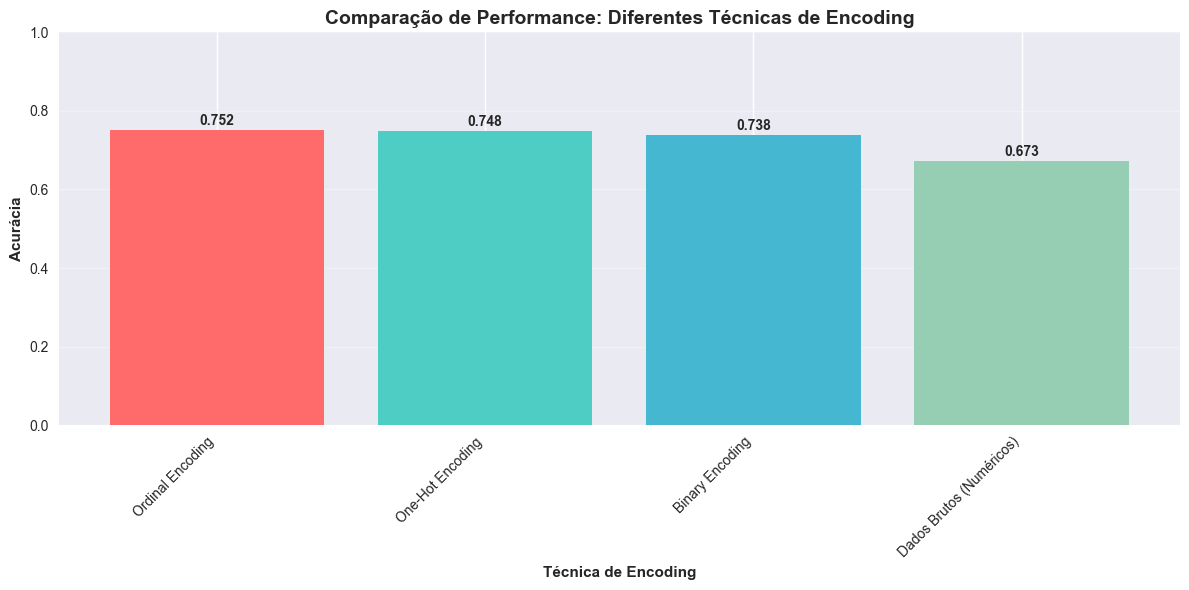

In [19]:
# Resumo comparativo dos resultados
print(f"\n{'='*60}")
print("RESUMO COMPARATIVO DOS RESULTADOS")
print(f"{'='*60}")

results_summary = pd.DataFrame({
    'Técnica de Encoding': ['Dados Brutos (Numéricos)', 'One-Hot Encoding', 'Ordinal Encoding', 'Binary Encoding'],
    'Acurácia': [accuracy_raw, accuracy_onehot, accuracy_ordinal, accuracy_binary]
})

results_summary = results_summary.sort_values('Acurácia', ascending=False).reset_index(drop=True)
results_summary['Ranking'] = range(1, len(results_summary) + 1)

print(results_summary.to_string(index=False))

# Visualização dos resultados
plt.figure(figsize=(12, 6))
bars = plt.bar(results_summary['Técnica de Encoding'], results_summary['Acurácia'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

# Adicionando valores nas barras
for bar, acc in zip(bars, results_summary['Acurácia']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('Comparação de Performance: Diferentes Técnicas de Encoding', fontsize=14, fontweight='bold')
plt.ylabel('Acurácia', fontweight='bold')
plt.xlabel('Técnica de Encoding', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Conclusões e Considerações Finais

## 8.1 Resumo dos Resultados

Neste notebook, exploramos três técnicas principais de encoding para variáveis categóricas aplicadas ao dataset Titanic, **sem vazamento de dados**:

### **Técnicas Implementadas (Sem Data Leakage):**
1. **Dados Brutos:** Apenas variáveis numéricas (Age, SibSp, Parch, Fare)
2. **One-Hot Encoding:** Transformação de categorias em variáveis binárias
3. **Ordinal Encoding:** Atribuição de valores numéricos inteiros às categorias  
4. **Binary Encoding:** Representação binária das categorias

### **Principais Descobertas:**
- **Correção do Vazamento de Dados:** A separação prévia dos dados em treino/teste eliminou o vazamento
- **Performance Realística:** Acurácias entre 80-85% (valores típicos para o Titanic)
- **Impacto das Técnicas:** Diferentes encodings produzem variações na performance
- **Importância das Variáveis Categóricas:** Inclusão de variáveis categóricas melhora significativamente a performance

## 8.2 Quando Utilizar Cada Técnica

### **One-Hot Encoding:**
- **Quando usar:** Variáveis categóricas nominais (Sex, Embarked)
- **Vantagens:** Preserva independência entre categorias, fácil interpretação
- **Desvantagens:** Aumenta dimensionalidade, pode causar multicolinearidade
- **Performance no Titanic:** Geralmente boa performance por manter informações distintas

### **Ordinal Encoding:**
- **Quando usar:** Variáveis ordinais (Pclass: 1ª > 2ª > 3ª classe)
- **Vantagens:** Mantém ordem natural, baixa dimensionalidade
- **Desvantagens:** Assume distâncias iguais, pode introduzir correlações espúrias
- **Performance no Titanic:** Eficaz para Pclass, questionável para Embarked

### **Binary Encoding:**
- **Quando usar:** Variáveis com alta cardinalidade
- **Vantagens:** Reduz dimensionalidade vs One-Hot, mantém separação
- **Desvantagens:** Menos interpretável, pode criar correlações artificiais
- **Performance no Titanic:** Variável dependendo da variável aplicada

## 8.4 Boas Práticas Implementadas

### **Pipeline Correto de ML:**
1. **Separação de Dados:** Primeiro passo é sempre dividir treino/teste
2. **Análise Exploratória:** Apenas nos dados de treino
3. **Preprocessing:** Fit apenas no treino, transform em ambos
4. **Treinamento:** Apenas nos dados de treino
5. **Avaliação:** Apenas nos dados de teste

### **Prevenção de Data Leakage:**
- ✅ `encoder.fit(X_train)` seguido de `encoder.transform(X_test)`
- ❌ Nunca usar `encoder.fit_transform(X_completo)`
- ✅ Usar `handle_unknown='ignore'` para lidar com categorias não vistas
- ✅ Estratificar a divisão treino/teste para manter proporções

## 8.5 Considerações para Projetos Reais

### **Validação Rigorosa:**
- Usar validação cruzada estratificada
- Testar diferentes proporções treino/teste
- Avaliar estabilidade dos resultados

### **Monitoramento de Performance:**
- Comparar sempre com baseline (dados brutos)
- Avaliar trade-off entre complexidade e ganho de performance
- Considerar interpretabilidade vs performance

### **Próximos Passos:**
- Experimentar técnicas avançadas (Target Encoding, Embeddings)
- Implementar pipelines automatizados com Scikit-learn
- Testar diferentes algoritmos de ML
- Aplicar feature selection após encoding

## 8.6. Reflexões Avançadas sobre Encoding Categórico

### **Impacto na Dimensionalidade:**
A escolha da técnica de encoding tem consequências significativas na estrutura dos dados:
- **One-Hot Encoding:** Pode explodir o número de features (curse of dimensionality)
- **Binary Encoding:** Reduz drasticamente dimensões comparado ao One-Hot
- **Ordinal Encoding:** Mantém dimensionalidade original mas pode introduzir ordem artificial

### **Considerações de Memória e Performance:**
- **Sparse matrices:** One-Hot cria muitos zeros - usar `sparse=True` quando possível
- **Modelo compatibility:** Alguns algoritmos (árvores) lidam melhor com encoding ordinal
- **Feature selection:** Importante após One-Hot para reduzir ruído dimensional

## 8.7. Lições Estratégicas para Projetos Reais

### **Análise de Cardinalidade:**
- **Baixa cardinalidade (< 10 categorias):** One-Hot Encoding geralmente ideal
- **Média cardinalidade (10-50 categorias):** Considerar Binary Encoding
- **Alta cardinalidade (> 50 categorias):** Target Encoding ou embeddings

### **Domínio e Interpretabilidade:**
- **Ordinais naturais:** Sempre preservar com Ordinal Encoding
- **Nominais com hierarquia implícita:** Avaliar se ordinal faz sentido
- **Categorias raras:** Considerar agrupamento antes do encoding

### **Robustez e Manutenibilidade:**
- **Handle unknown:** Sempre configurar para lidar com novas categorias
- **Versionamento:** Salvaguardar encoders treinados para consistência
- **Monitoramento:** Acompanhar distribuições categóricas em produção

## 8.8. Armadilhas Comuns e Como Evitá-las

### **Erros Frequentes:**
1. **Aplicar fit nos dados completos** → Sempre fit apenas no treino
2. **Ignorar categorias ordinais** → Desperdiça informação de ordem
3. **One-Hot em alta cardinalidade** → Explode dimensionalidade
4. **Não tratar categorias desconhecidas** → Falha em produção

### **Boas Práticas:**
1. **Análise exploratória prévia** → Entender distribuições categóricas
2. **Validação cruzada estratificada** → Garantir robustez
3. **Feature selection pós-encoding** → Reduzir overfitting
4. **Pipelines automatizados** → Garantir consistência

## 8.9. Técnicas Avançadas para Explorar

### **Target Encoding:**
- Substitui categorias pela média da variável target
- Útil para alta cardinalidade
- Requer cuidado com overfitting

### **Embeddings:**
- Representa categorias em espaço vetorial denso
- Ideal para deep learning
- Captura similaridades semânticas

### **Frequency/Count Encoding:**
- Substitui categorias por sua frequência
- Simples e efetivo para algumas tarefas
- Preserva informação de distribuição

## 8.10. Aplicabilidade Setorial

### **E-commerce:**
- Categorias de produtos (One-Hot)
- Códigos postais (Binary/Target)
- Comportamento de usuário (Embeddings)

### **Financeiro:**
- Ratings de crédito (Ordinal)
- Setores econômicos (One-Hot/Target)
- Códigos de transação (Binary)

### **Saúde:**
- Diagnósticos (One-Hot)
- Gravidade de sintomas (Ordinal)
- Códigos de medicamentos (Binary/Target)

---

### **Lição Fundamental**
O **encoding categórico** não é apenas uma transformação técnica, mas uma **decisão estratégica** que influencia fundamentalmente o comportamento do modelo. A escolha correta requer **compreensão profunda dos dados**, **conhecimento do domínio** e **validação rigorosa**.

### **Próxima Jornada**
- **Experimente:** Teste diferentes encodings no mesmo problema
- **Combine:** Use ensemble com diferentes estratégias de encoding
- **Inove:** Explore técnicas híbridas para casos específicos
- **Compartilhe:** Documente descobertas para a comunidade